# IN-GPS 캡스톤 — Soft Sensor: 표면+상온 → 코어온도 예측 (화재예방)

**목적:** ESP32에서 **표면(ambient) + 상온(room) 써미스터만으로 코어온도를 추정**.
코어 센서는 양산에 포함하지 않는 **soft sensor / virtual sensor** 패턴.

**입력 (7 features):** T_ambient, T_room, dT_ambient/dt, ΔT(amb−room), T_ambient_EMA, T_amb_integral, t_sec
**출력 (multi-horizon, 절대값):** T_core(t), T_core(t+30s), T_core(t+60s), T_core(t+120s)
- H=0: 현재 코어 추정 (소프트 센서)
- H>0: 미래 코어 예측 (조기 경보)
**부산물:** 임계온도 도달까지 남은 시간 (TTT, 다중 호라이즌 예측값에서 외삽)

**데이터:** `시나리오1-A-1파생 파라미터-온도 기반(05_04).csv` (2026-05-04 실측, 1Hz)
**타겟 환경:** ESP32 엣지 추론

## Section 1: 라이브러리 및 데이터 로드

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings, os, platform

warnings.filterwarnings("ignore")

# --- 한글 폰트 ---
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# --- 스타일 ---
sns.set_style("whitegrid")
BLUE = "#1565C0"
BLUE_LIGHT = "#90CAF9"
ORANGE = "#EF6C00"
RED = "#C62828"
PALETTE = sns.color_palette([BLUE, "#1976D2", "#1E88E5", "#42A5F5", BLUE_LIGHT])
FIGSIZE = (10, 6)
FIGURES_DIR = "../output/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ─── 모델링 파라미터 ─────────────────────────────
HORIZONS = [0, 30, 60, 120]   # H=0 = 현재 코어 추정 (soft sensor), H>0 = 미래 예측
PRIMARY_H = 60                # 시각화/요약 대표 호라이즌
EMA_ALPHA = 0.1
DTDT_WINDOW = 3

# ─── 피처(7) — 표면+상온만 ───────────────────────
FEATURE_COLS = [
    "T_ambient",        # 단일 외부 표면 써미스터 (5채널 mean을 프록시로)
    "T_room",           # 상온
    "dT_ambient_dt",    # 표면 상승 속도
    "delta_amb_room",   # T_ambient − T_room  (환경 위로 얼마나 데워졌나)
    "T_ambient_ema",    # EMA(α=0.1) 평활
    "T_amb_integral",   # ∫(T_ambient − T_room) dt  누적 열량 비례
    "t_sec",            # 운전 경과 시간
]
# ─── 타깃 — 절대 T_core (코어 측정 안 받음) ──────
TARGET_PREFIX = "core_t"
TARGETS = [f"{TARGET_PREFIX}{h}" for h in HORIZONS]
PRIMARY_TARGET = f"{TARGET_PREFIX}{PRIMARY_H}"


In [2]:
# CSV 로드 (한글 컬럼명 + 헤더 중복 → 위치 인덱스)
CSV_PATH = "../data/시나리오1-A-1파생 파라미터-온도 기반(05_04).csv"
RAW = pd.read_csv(CSV_PATH, encoding="cp949", header=None, skiprows=2)

# K~N(10~13) + P(15): 코어 5채널 (※타깃 생성에만 사용, 모델 입력은 아님)
# Q~S(16~18) + U~V(20~21): 외부 5채널
# W(22): 상온
# H(7): t_sec
cores = RAW[[10, 11, 12, 13, 15]].apply(pd.to_numeric, errors="coerce")
ambs  = RAW[[16, 17, 18, 20, 21]].apply(pd.to_numeric, errors="coerce")

raw = pd.DataFrame({
    "T_core":    cores.mean(axis=1),     # ※ 학습 시 타깃 생성에만 사용 (입력 X)
    "T_ambient": ambs.mean(axis=1),      # 단일 채널 프록시 (양산: 1채널)
    "T_room":    pd.to_numeric(RAW[22], errors="coerce"),
    "t_sec":     pd.to_numeric(RAW[7],  errors="coerce"),
}).dropna().reset_index(drop=True)

# ─── 피처 엔지니어링 (ambient + room 만으로) ────
dt = raw["t_sec"].diff().median()  # ≈ 1.0
raw["dT_ambient_dt"]  = raw["T_ambient"].diff(DTDT_WINDOW) / (DTDT_WINDOW * dt)
raw["delta_amb_room"] = raw["T_ambient"] - raw["T_room"]
raw["T_ambient_ema"]  = raw["T_ambient"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
raw["T_amb_integral"] = ((raw["T_ambient"] - raw["T_room"]) * dt).cumsum()

# ─── 타깃 (절대 T_core) ─────────────────────────
# H=0: 현재 코어 (소프트 센서)
# H>0: 미래 코어
for h in HORIZONS:
    raw[f"{TARGET_PREFIX}{h}"] = raw["T_core"].shift(-h) if h > 0 else raw["T_core"]

n_raw = len(raw)
df = raw[FEATURE_COLS + TARGETS].dropna().reset_index(drop=True)
print(f"원본 행수: {n_raw}, NaN 제거 후: {len(df)} (제외 {n_raw - len(df)}행 — 차분 시작 + 호라이즌 끝)")
print("\n=== Targets (절대 T_core, °C) 통계 ===")
print(df[TARGETS].describe().round(3))
print("\n=== Features (입력) 요약 ===")
print(df[FEATURE_COLS].describe().round(3).T[["mean","std","min","max"]])


원본 행수: 3693, NaN 제거 후: 3570 (제외 123행 — 차분 시작 + 호라이즌 끝)

=== Targets (절대 T_core, °C) 통계 ===
        core_t0  core_t30  core_t60  core_t120
count  3570.000  3570.000  3570.000   3570.000
mean     33.860    33.973    34.076     34.272
std       3.361     3.242     3.148      2.971
min      22.761    24.704    25.214     25.967
25%      32.026    32.195    32.346     32.634
50%      35.126    35.192    35.263     35.400
75%      36.571    36.592    36.625     36.692
max      37.202    37.219    37.223     37.271

=== Features (입력) 요약 ===
                    mean       std      min        max
T_ambient         28.607     2.901   20.727     31.717
T_room            23.356     0.387   21.936     24.415
dT_ambient_dt      0.003     0.010   -0.034      0.045
delta_amb_room     5.251     3.078   -2.843      8.968
T_ambient_ema     28.579     2.923   20.734     31.675
T_amb_integral  6414.341  6040.887 -422.895  18736.249
t_sec           1787.497  1030.715    2.994   3571.993


## ⚠️ 현재 데이터셋 한계

이 데이터는 **정상 운전 1회 (61분, 코어 22.8 → 37.2°C, 마지막 60s 상승 0.04°C)** 만 포함합니다. 즉 **스테디스테이트로 수렴한 정상 시나리오**입니다.

**한계:**
- 화재 위험 영역(80°C 이상)의 거동을 본 적 없음 → 임계 근처 예측은 외삽
- "이상 발열" 패턴 (locked rotor, 환기 차단, 과부하) 데이터 없음
- 모델 성능 지표(R²)는 정상 거동에 대해서만 유효

**Soft sensor 관점 추가 한계:**
- 입력에 코어가 없으므로 **이상 발열의 직접 신호 없음** — 표면+상온 변화로만 추론
- 표면이 코어를 잘 추종할 때만 잘 동작 (정상 운전은 OK, 급격한 부하 변화 시 표면 지연으로 추정 오차 ↑)

**필요한 추가 데이터:**
- 정격 부하 초과 운전 (전류 ↑ → 빠른 상승)
- 강제 냉각 차단 (팬 막기 / 통기구 폐쇄)
- 다양한 상온 조건 (0°C, 40°C 등)

데이터 추가 시 이 노트북 그대로 재실행하면 자동으로 통합됩니다.

## Section 2: 탐색적 데이터 분석 (EDA)

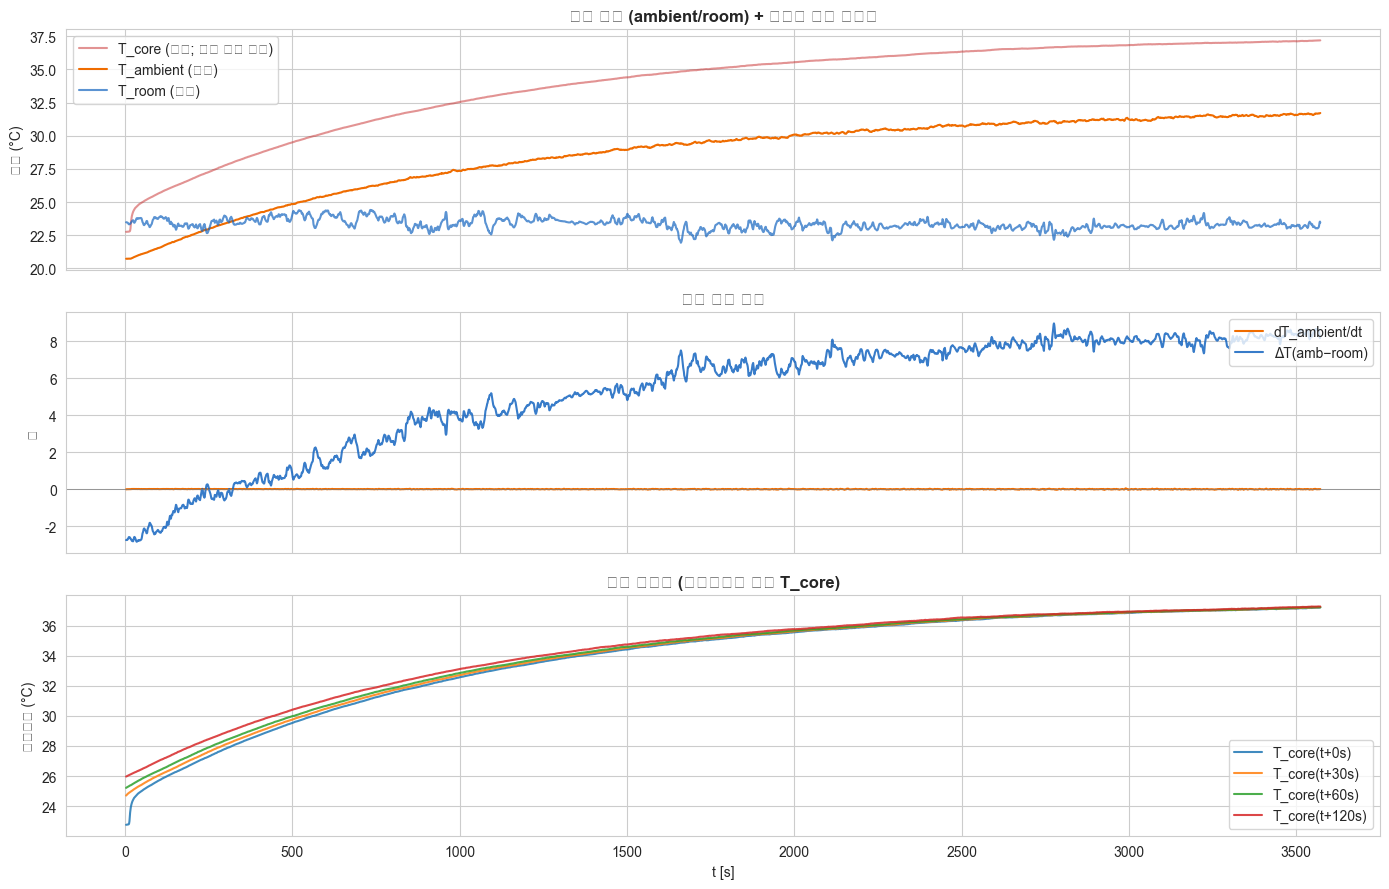

In [3]:
# 피처 + 타깃 시계열 (시간축)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# (1) 측정 가능한 입력 (T_ambient, T_room) + 참고용 T_core (모델 입력 X, 타깃 검증용)
axes[0].plot(df["t_sec"], raw["T_core"].iloc[:len(df)+0],  color=RED,    label="T_core (참고; 모델 입력 아님)", alpha=0.5)
axes[0].plot(df["t_sec"], df["T_ambient"], color=ORANGE, label="T_ambient (입력)")
axes[0].plot(df["t_sec"], df["T_room"],    color=BLUE,   label="T_room (입력)", alpha=0.7)
axes[0].set_ylabel("온도 (°C)"); axes[0].legend(loc="upper left")
axes[0].set_title("입력 센서 (ambient/room) + 참고용 코어 시계열", fontweight="bold")

# (2) ambient 도함수 + ΔT
axes[1].plot(df["t_sec"], df["dT_ambient_dt"], color=ORANGE, label="dT_ambient/dt")
axes[1].plot(df["t_sec"], df["delta_amb_room"], color=BLUE,  label="ΔT(amb−room)", alpha=0.85)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("값"); axes[1].legend(loc="upper right")
axes[1].set_title("입력 파생 피처", fontweight="bold")

# (3) 타깃 (절대 T_core, 호라이즌별)
for h in HORIZONS:
    axes[2].plot(df["t_sec"], df[f"{TARGET_PREFIX}{h}"], label=f"T_core(t+{h}s)", alpha=0.85)
axes[2].set_xlabel("t [s]"); axes[2].set_ylabel("코어온도 (°C)")
axes[2].legend(loc="lower right")
axes[2].set_title("타깃 시계열 (호라이즌별 절대 T_core)", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


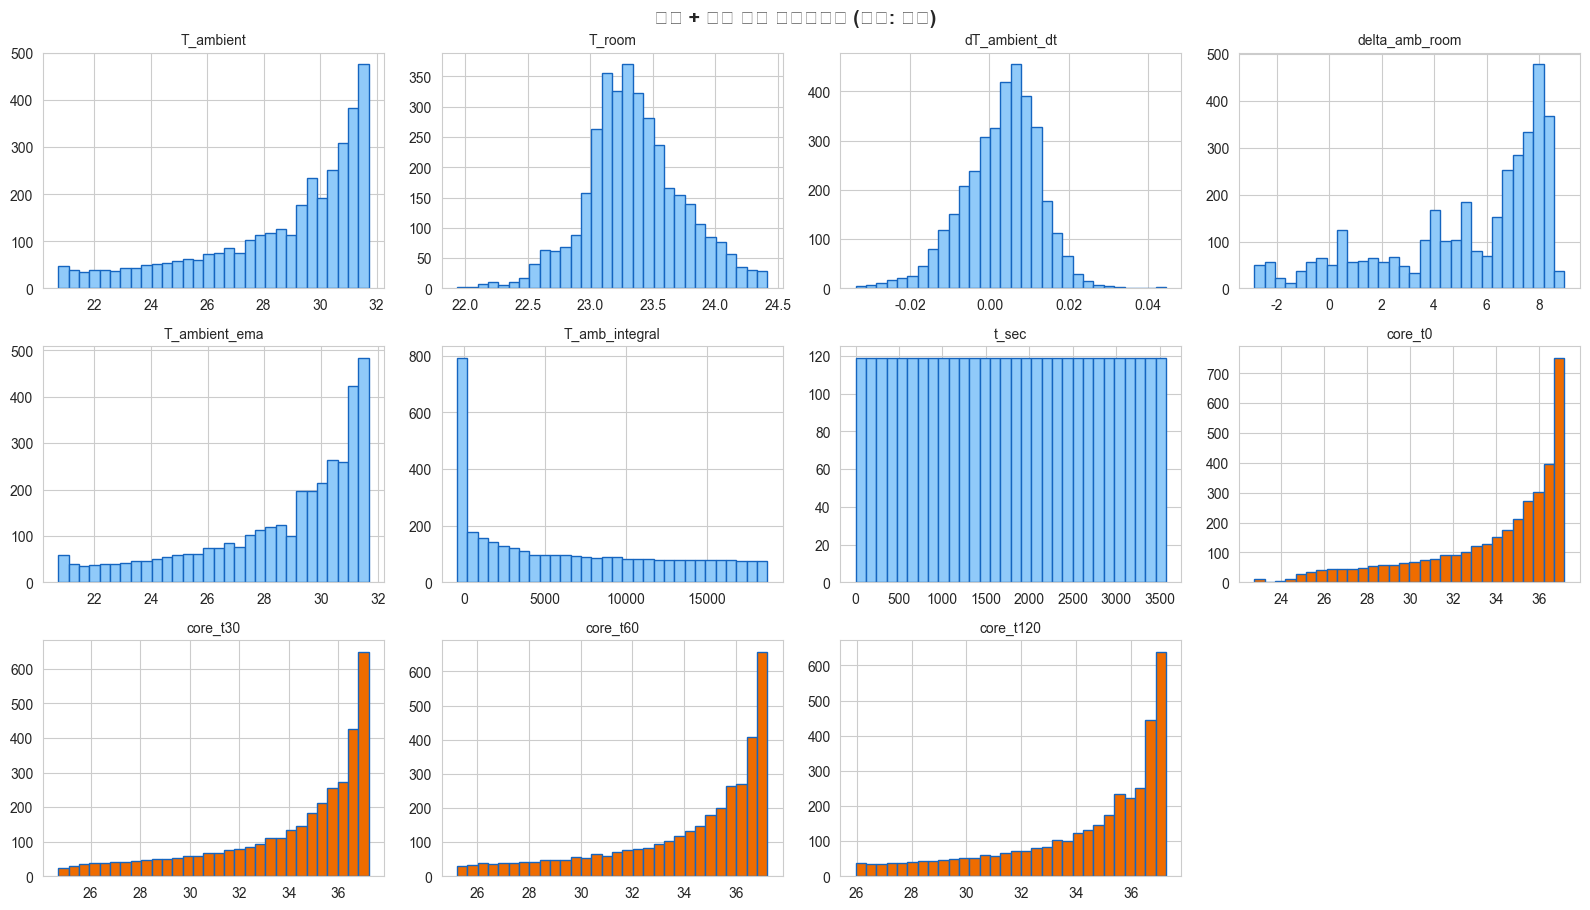

In [4]:
# 피처 분포 히스토그램 (10 features + 3 targets = 4×4 grid, 3칸 비움)
all_cols = FEATURE_COLS + TARGETS
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    color = ORANGE if col in TARGETS else BLUE_LIGHT
    axes[i].hist(df[col], bins=30, color=color, edgecolor=BLUE)
    axes[i].set_title(col, fontsize=10)

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("피처 + 타깃 분포 히스토그램 (주황: 타깃)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


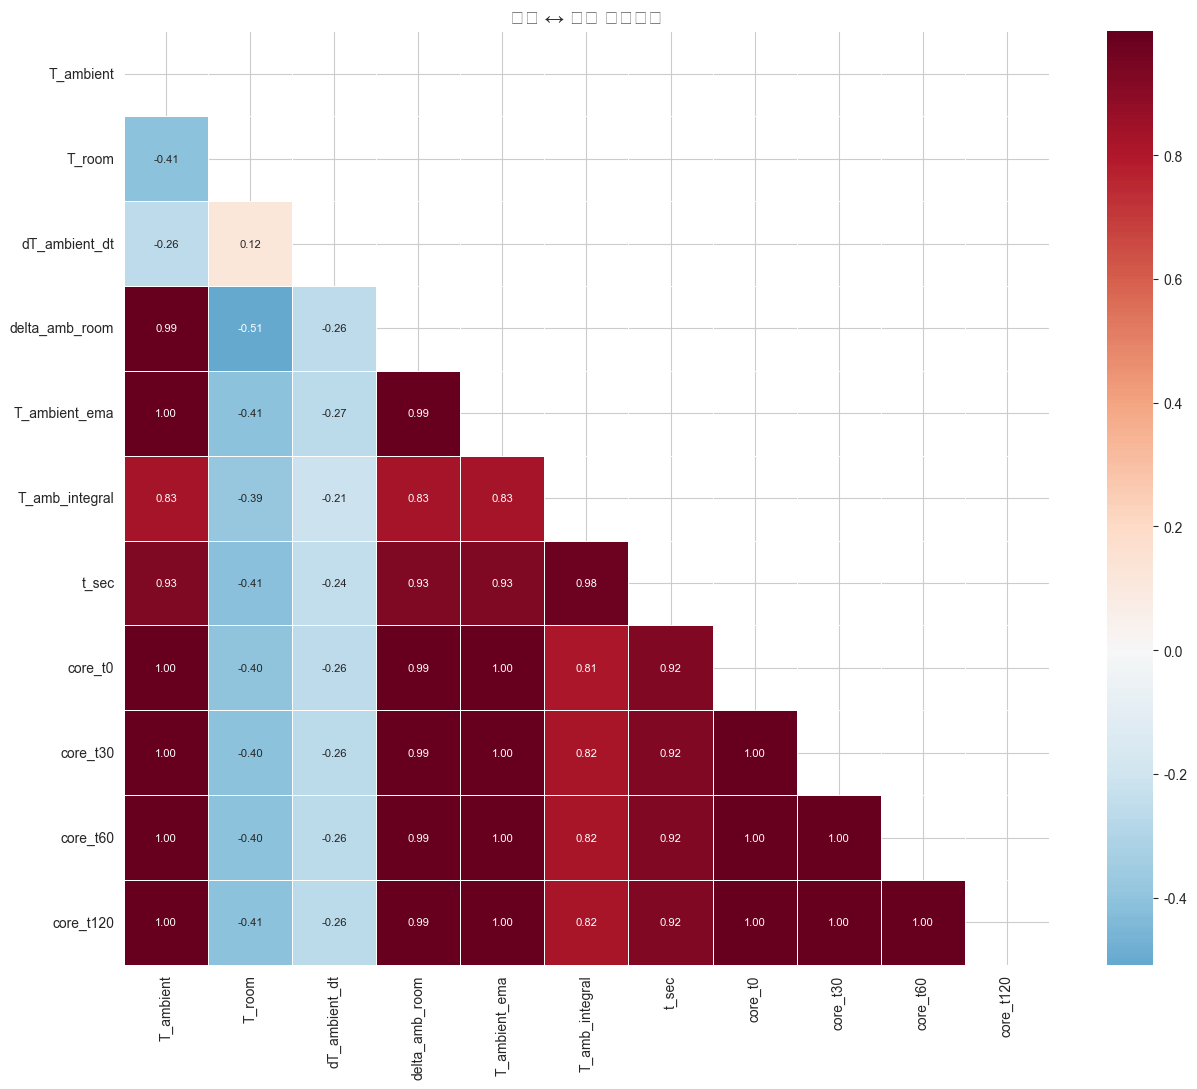

In [5]:
# 상관관계 히트맵 (features ↔ targets 관계 확인)
fig, ax = plt.subplots(figsize=(13, 11))
corr = df[FEATURE_COLS + TARGETS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("피처 ↔ 타깃 상관관계", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


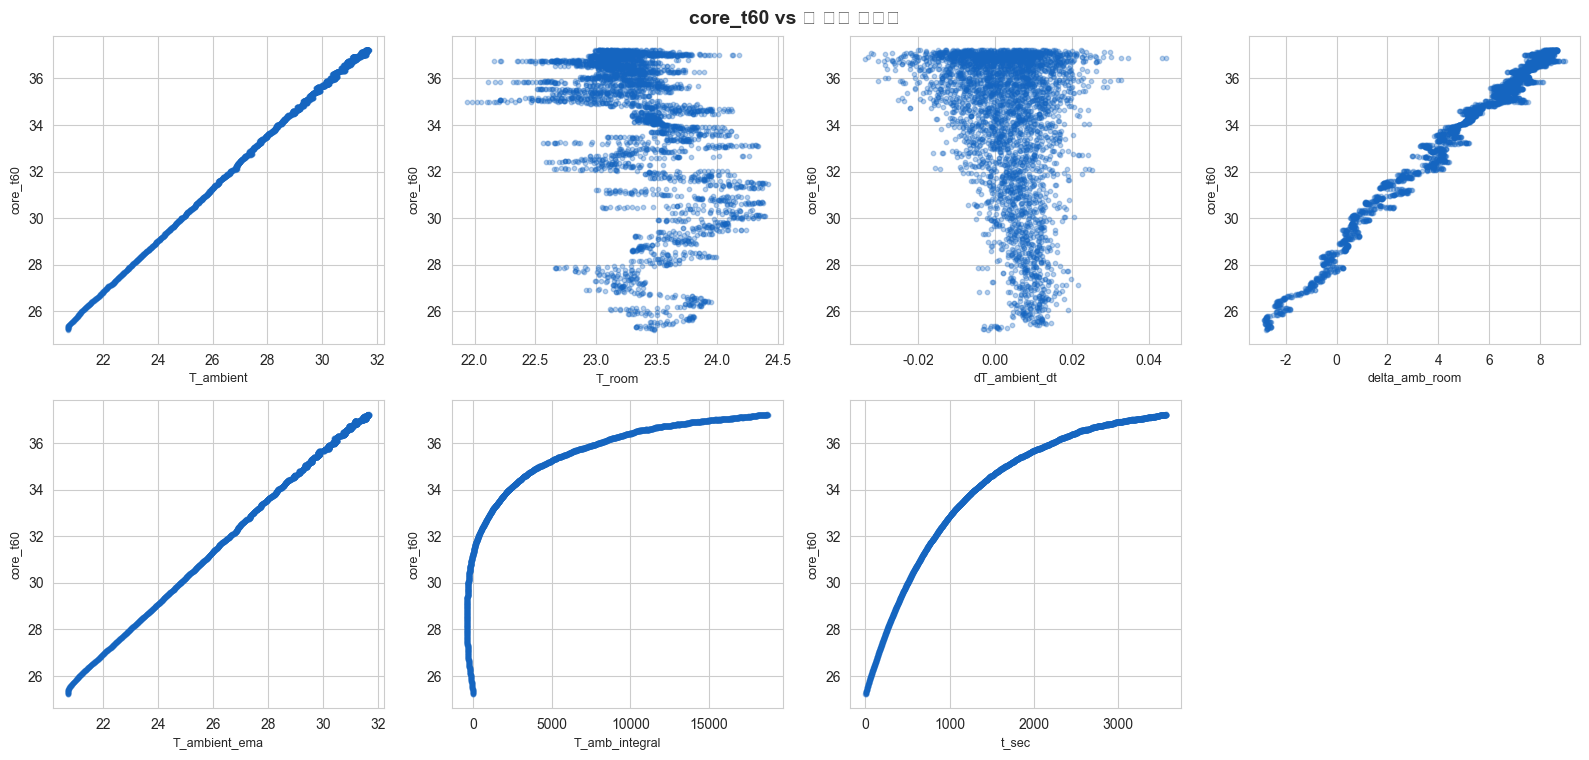

In [6]:
# 대표 호라이즌(60s) vs 각 피처 산점도
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].scatter(df[col], df[PRIMARY_TARGET], alpha=0.3, s=10, color=BLUE)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(PRIMARY_TARGET, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{PRIMARY_TARGET} vs 각 피처 산점도", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_scatter_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3: 전처리

In [7]:
# 피처는 호라이즌과 무관하게 동일 → 한 번만 split & scale
X_all = df[FEATURE_COLS].values
Y_all = {h: df[f"{TARGET_PREFIX}{h}"].values for h in HORIZONS}

# random split (시계열 leakage 우려 있으나 본 데이터는 정상상태 단일 운전 → 분포 동일)
# 추후 다양한 시나리오 추가되면 GroupKFold(by=run_id)로 전환 권장
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = X_all[idx_train]
X_test  = X_all[idx_test]
y_train = {h: Y_all[h][idx_train] for h in HORIZONS}
y_test  = {h: Y_all[h][idx_test]  for h in HORIZONS}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
for h in HORIZONS:
    yh = Y_all[h]
    print(f"  ΔT_core(t+{h:3d}s) 범위: [{yh.min():+.3f}, {yh.max():+.3f}] °C  (mean {yh.mean():+.3f})")


Train: (2856, 7)  Test: (714, 7)
  ΔT_core(t+  0s) 범위: [+22.761, +37.202] °C  (mean +33.860)
  ΔT_core(t+ 30s) 범위: [+24.704, +37.219] °C  (mean +33.973)
  ΔT_core(t+ 60s) 범위: [+25.214, +37.223] °C  (mean +34.076)
  ΔT_core(t+120s) 범위: [+25.967, +37.271] °C  (mean +34.272)


## Section 4: PCA(SVD) 분석

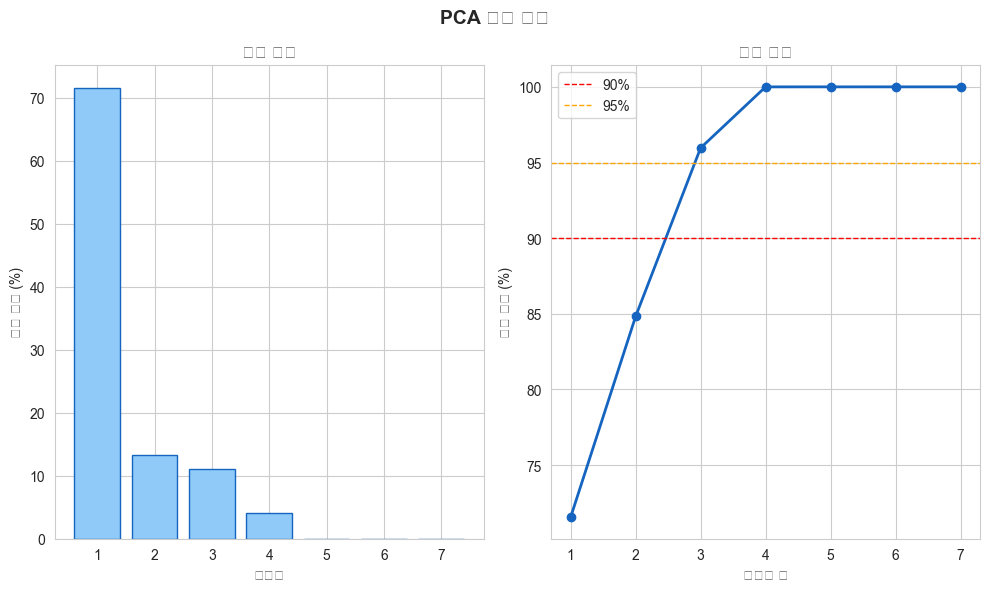

90%: 3개 / 95%: 3개 → SVD에 사용: 3개


In [8]:
pca_full = PCA(n_components=len(FEATURE_COLS))
pca_full.fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(range(1, len(explained)+1), explained * 100, color=BLUE_LIGHT, edgecolor=BLUE)
axes[0].set_xlabel("주성분"); axes[0].set_ylabel("설명 분산 (%)"); axes[0].set_title("개별 분산")
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker="o", color=BLUE, linewidth=2)
axes[1].axhline(90, color="red",    linestyle="--", linewidth=1, label="90%")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1, label="95%")
axes[1].set_xlabel("주성분 수"); axes[1].set_ylabel("누적 분산 (%)"); axes[1].set_title("누적 분산")
axes[1].set_xticks(range(1, len(cumulative)+1)); axes[1].legend()

plt.suptitle("PCA 분산 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1
N_COMPONENTS = n_95
print(f"90%: {n_90}개 / 95%: {n_95}개 → SVD에 사용: {N_COMPONENTS}개")


In [9]:
pca_table = pd.DataFrame({
    "주성분 수": range(1, len(explained)+1),
    "개별 분산 (%)": (explained * 100).round(2),
    "누적 분산 (%)": (cumulative * 100).round(2),
}).set_index("주성분 수")
pca_table


,개별 분산 (%),누적 분산 (%)
주성분 수,,
1,71.56,71.56
2,13.27,84.83
3,11.14,95.96
4,4.04,100.00
5,0.00,100.00
6,0.00,100.00
7,0.00,100.00


## Section 5: 호라이즌별 모델 학습 및 비교

In [10]:
def make_models():
    return {
        "Linear":              LinearRegression(),
        f"SVD({N_COMPONENTS})+LR": Pipeline([("pca", PCA(n_components=N_COMPONENTS)),
                                              ("lr",  LinearRegression())]),
        "Poly(2)+LR":          Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                         ("lr",   LinearRegression())]),
        "DT(d=5)":             DecisionTreeRegressor(max_depth=5, random_state=42),
        "XGB":                 XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                            random_state=42, verbosity=0),
    }

results_long = []         # 길게 펼친 결과 (호라이즌 × 모델)
predictions  = {}         # predictions[h][model_name] = y_pred

for h in HORIZONS:
    print(f"\n────── 호라이즌 t+{h}s ──────")
    predictions[h] = {}
    for name, model in make_models().items():
        model.fit(X_train_sc, y_train[h])
        y_pred = model.predict(X_test_sc)
        mae  = mean_absolute_error(y_test[h], y_pred)
        rmse = mean_squared_error(y_test[h], y_pred) ** 0.5
        r2   = r2_score(y_test[h], y_pred)
        print(f"  [{name:14s}] MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
        results_long.append({"horizon": h, "model": name,
                             "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R²": round(r2, 4)})
        predictions[h][name] = y_pred

results_df = pd.DataFrame(results_long)
results_df.set_index(["horizon", "model"]).style.background_gradient(cmap="Blues", subset=["R²"]).format(precision=4)



────── 호라이즌 t+0s ──────
  [Linear        ] MAE=0.055  RMSE=0.116  R²=0.9989
  [SVD(3)+LR     ] MAE=0.627  RMSE=0.757  R²=0.9541
  [Poly(2)+LR    ] MAE=0.031  RMSE=0.054  R²=0.9998
  [DT(d=5)       ] MAE=0.092  RMSE=0.120  R²=0.9988
  [XGB           ] MAE=0.013  RMSE=0.025  R²=1.0000

────── 호라이즌 t+30s ──────
  [Linear        ] MAE=0.033  RMSE=0.047  R²=0.9998
  [SVD(3)+LR     ] MAE=0.598  RMSE=0.708  R²=0.9570
  [Poly(2)+LR    ] MAE=0.016  RMSE=0.020  R²=1.0000
  [DT(d=5)       ] MAE=0.086  RMSE=0.107  R²=0.9990
  [XGB           ] MAE=0.011  RMSE=0.018  R²=1.0000

────── 호라이즌 t+60s ──────
  [Linear        ] MAE=0.031  RMSE=0.042  R²=0.9998
  [SVD(3)+LR     ] MAE=0.578  RMSE=0.682  R²=0.9576
  [Poly(2)+LR    ] MAE=0.015  RMSE=0.019  R²=1.0000
  [DT(d=5)       ] MAE=0.081  RMSE=0.100  R²=0.9991
  [XGB           ] MAE=0.011  RMSE=0.016  R²=1.0000

────── 호라이즌 t+120s ──────
  [Linear        ] MAE=0.030  RMSE=0.039  R²=0.9998
  [SVD(3)+LR     ] MAE=0.541  RMSE=0.638  R²=0.9584
  [Poly(2)+L

## Section 6: 5-fold 교차검증 (호라이즌별)

t+  0s [Linear        ] CV MAE = 0.055 ± 0.002
t+  0s [SVD(3)+LR     ] CV MAE = 0.617 ± 0.010
t+  0s [Poly(2)+LR    ] CV MAE = 0.029 ± 0.002
t+  0s [DT(d=5)       ] CV MAE = 0.088 ± 0.002
t+  0s [XGB           ] CV MAE = 0.013 ± 0.001
t+ 30s [Linear        ] CV MAE = 0.033 ± 0.001
t+ 30s [SVD(3)+LR     ] CV MAE = 0.586 ± 0.009
t+ 30s [Poly(2)+LR    ] CV MAE = 0.016 ± 0.001
t+ 30s [DT(d=5)       ] CV MAE = 0.081 ± 0.002
t+ 30s [XGB           ] CV MAE = 0.011 ± 0.001
t+ 60s [Linear        ] CV MAE = 0.032 ± 0.000
t+ 60s [SVD(3)+LR     ] CV MAE = 0.567 ± 0.009
t+ 60s [Poly(2)+LR    ] CV MAE = 0.016 ± 0.000
t+ 60s [DT(d=5)       ] CV MAE = 0.078 ± 0.003
t+ 60s [XGB           ] CV MAE = 0.011 ± 0.001
t+120s [Linear        ] CV MAE = 0.030 ± 0.001
t+120s [SVD(3)+LR     ] CV MAE = 0.531 ± 0.008
t+120s [Poly(2)+LR    ] CV MAE = 0.015 ± 0.000
t+120s [DT(d=5)       ] CV MAE = 0.074 ± 0.003
t+120s [XGB           ] CV MAE = 0.011 ± 0.001


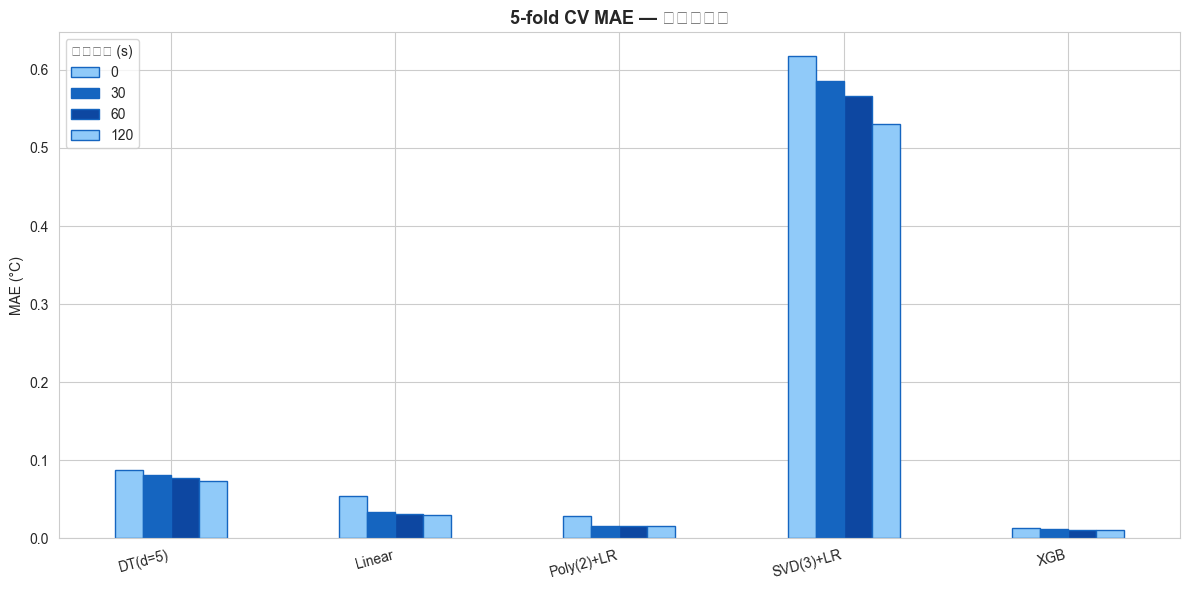

CV MAE 평균  CV MAE std
horizon model                            
0       Linear         0.0547      0.0022
        SVD(3)+LR      0.6173      0.0099
        Poly(2)+LR     0.0287      0.0021
        DT(d=5)        0.0877      0.0017
        XGB            0.0130      0.0015
30      Linear         0.0335      0.0007
        SVD(3)+LR      0.5863      0.0089
        Poly(2)+LR     0.0157      0.0005
        DT(d=5)        0.0811      0.0022
        XGB            0.0113      0.0007
60      Linear         0.0317      0.0005
        SVD(3)+LR      0.5667      0.0088
        Poly(2)+LR     0.0156      0.0003
        DT(d=5)        0.0776      0.0025
        XGB            0.0111      0.0006
120     Linear         0.0303      0.0008
        SVD(3)+LR      0.5309      0.0080
        Poly(2)+LR     0.0152      0.0004
        DT(d=5)        0.0740      0.0026
        XGB            0.0107      0.0007

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_long = []

for h in HORIZONS:
    for name, model in make_models().items():
        scores = -cross_val_score(model, X_train_sc, y_train[h],
                                  cv=kf, scoring="neg_mean_absolute_error")
        cv_long.append({"horizon": h, "model": name,
                        "CV MAE 평균": round(scores.mean(), 4),
                        "CV MAE std": round(scores.std(), 4)})
        print(f"t+{h:3d}s [{name:14s}] CV MAE = {scores.mean():.3f} ± {scores.std():.3f}")

cv_df = pd.DataFrame(cv_long)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = cv_df.pivot(index="model", columns="horizon", values="CV MAE 평균")
pivot.plot(kind="bar", ax=ax, color=[BLUE_LIGHT, BLUE, "#0D47A1"], edgecolor=BLUE)
ax.set_ylabel("MAE (°C)"); ax.set_xlabel("")
ax.set_title("5-fold CV MAE — 호라이즌별", fontsize=13, fontweight="bold")
ax.legend(title="호라이즌 (s)", loc="upper left")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_cv_mae.png", dpi=150, bbox_inches="tight")
plt.show()
cv_df.set_index(["horizon", "model"])


## Section 7: 최종 모델 시각화 (대표 호라이즌)

In [12]:
# 호라이즌별 최고 R² 모델 자동 선택
best_per_h = (results_df.loc[results_df.groupby("horizon")["R²"].idxmax()]
              [["horizon", "model", "MAE", "RMSE", "R²"]]
              .reset_index(drop=True))
print("=== 호라이즌별 최고 모델 ===")
print(best_per_h.to_string(index=False))
print()

BEST_MODEL_NAME = best_per_h.loc[best_per_h["horizon"] == PRIMARY_H, "model"].values[0]
y_pred_best = predictions[PRIMARY_H][BEST_MODEL_NAME]
y_true_best = y_test[PRIMARY_H]
residuals   = y_true_best - y_pred_best
print(f"대표 호라이즌(t+{PRIMARY_H}s) 최종 모델: {BEST_MODEL_NAME}")


=== 호라이즌별 최고 모델 ===
 horizon      model    MAE   RMSE  R²
       0        XGB 0.0126 0.0248 1.0
      30 Poly(2)+LR 0.0160 0.0199 1.0
      60 Poly(2)+LR 0.0154 0.0192 1.0
     120 Poly(2)+LR 0.0146 0.0186 1.0

대표 호라이즌(t+60s) 최종 모델: Poly(2)+LR


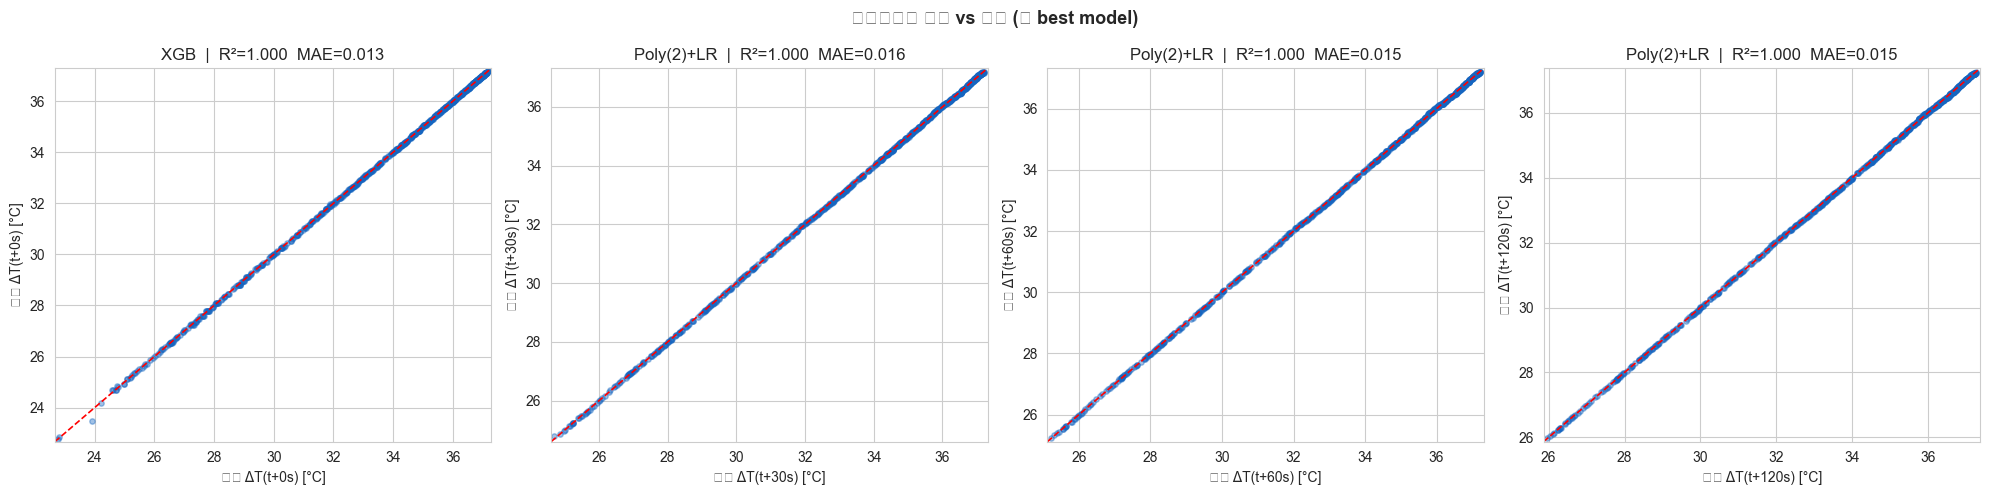

In [13]:
# 호라이즌 3개 동시 — 예측 vs 실제 (best per horizon)
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5*len(HORIZONS), 5))
if len(HORIZONS) == 1:
    axes = [axes]

for i, h in enumerate(HORIZONS):
    best_name = best_per_h.loc[best_per_h["horizon"] == h, "model"].values[0]
    yp = predictions[h][best_name]
    yt = y_test[h]
    lo = min(yt.min(), yp.min()) - 0.1
    hi = max(yt.max(), yp.max()) + 0.1
    axes[i].scatter(yt, yp, alpha=0.4, s=15, color=BLUE)
    axes[i].plot([lo, hi], [lo, hi], "r--", linewidth=1.2)
    axes[i].set_xlim(lo, hi); axes[i].set_ylim(lo, hi)
    axes[i].set_xlabel(f"실제 ΔT(t+{h}s) [°C]")
    axes[i].set_ylabel(f"예측 ΔT(t+{h}s) [°C]")
    r2 = r2_score(yt, yp)
    mae = mean_absolute_error(yt, yp)
    axes[i].set_title(f"{best_name}  |  R²={r2:.3f}  MAE={mae:.3f}")

plt.suptitle("호라이즌별 예측 vs 실제 (각 best model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


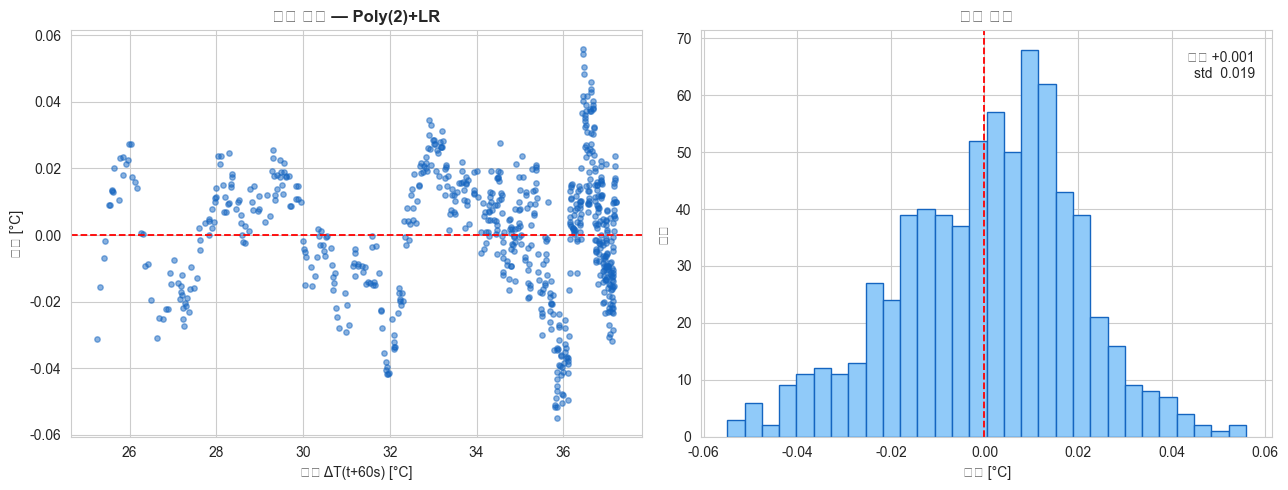

In [14]:
# 잔차 플롯 (대표 호라이즌)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=15, color=BLUE)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.3)
axes[0].set_xlabel(f"예측 ΔT(t+{PRIMARY_H}s) [°C]"); axes[0].set_ylabel("잔차 [°C]")
axes[0].set_title(f"잔차 플롯 — {BEST_MODEL_NAME}", fontweight="bold")

axes[1].hist(residuals, bins=30, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.3)
axes[1].set_xlabel("잔차 [°C]"); axes[1].set_ylabel("빈도")
axes[1].set_title("잔차 분포", fontweight="bold")
axes[1].text(0.97, 0.95, f"평균 {residuals.mean():+.3f}\nstd  {residuals.std():.3f}",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 8: 결과 요약

=== 호라이즌 × 모델 통합 비교표 ===
                       MAE    RMSE      R²  CV MAE 평균  CV MAE std
horizon model                                                    
0       Linear      0.0546  0.1160  0.9989     0.0547      0.0022
        SVD(3)+LR   0.6273  0.7572  0.9541     0.6173      0.0099
        Poly(2)+LR  0.0312  0.0543  0.9998     0.0287      0.0021
        DT(d=5)     0.0923  0.1203  0.9988     0.0877      0.0017
        XGB         0.0126  0.0248  1.0000     0.0130      0.0015
30      Linear      0.0331  0.0468  0.9998     0.0335      0.0007
        SVD(3)+LR   0.5985  0.7081  0.9570     0.5863      0.0089
        Poly(2)+LR  0.0160  0.0199  1.0000     0.0157      0.0005
        DT(d=5)     0.0857  0.1070  0.9990     0.0811      0.0022
        XGB         0.0115  0.0176  1.0000     0.0113      0.0007
60      Linear      0.0314  0.0419  0.9998     0.0317      0.0005
        SVD(3)+LR   0.5780  0.6823  0.9576     0.5667      0.0088
        Poly(2)+LR  0.0154  0.0192  1.0000     0.01

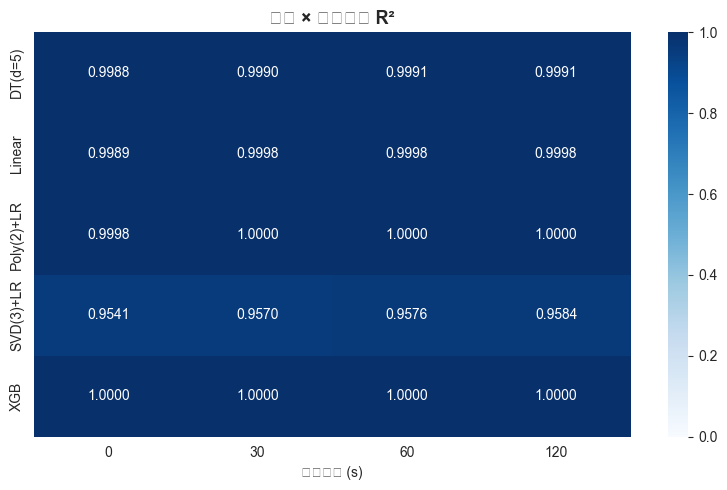

In [15]:
# 통합 요약: 테스트 + CV
summary = results_df.merge(cv_df, on=["horizon", "model"])
summary = summary.set_index(["horizon", "model"])
print("=== 호라이즌 × 모델 통합 비교표 ===")
print(summary.to_string())

# 모델 × 호라이즌 R² 히트맵
fig, ax = plt.subplots(figsize=(8, 5))
r2_pivot = results_df.pivot(index="model", columns="horizon", values="R²")
sns.heatmap(r2_pivot, annot=True, fmt=".4f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("모델 × 호라이즌 R²", fontsize=13, fontweight="bold")
ax.set_xlabel("호라이즌 (s)"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_r2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


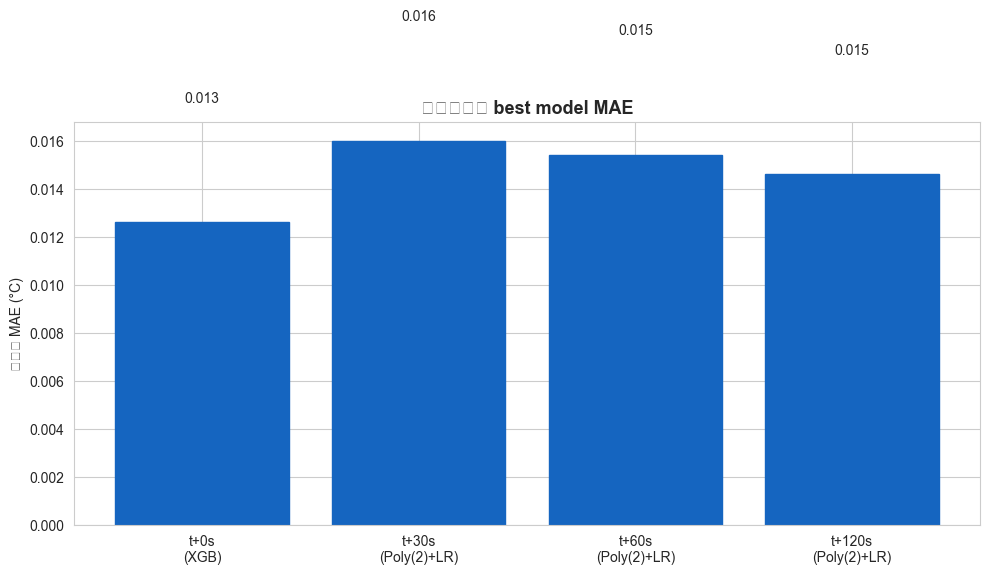


저장된 그래프:
  ../output/figures/.ipynb_checkpoints
  ../output/figures/00_timeseries.png
  ../output/figures/01_feature_distributions.png
  ../output/figures/02_correlation_heatmap.png
  ../output/figures/03_scatter_vs_target.png
  ../output/figures/04_pca_variance.png
  ../output/figures/05_cv_mae.png
  ../output/figures/06_pred_vs_actual.png
  ../output/figures/07_residual_plot.png
  ../output/figures/07_residuals.png
  ../output/figures/08_r2_heatmap.png
  ../output/figures/08_residual_hist.png
  ../output/figures/09_best_mae_per_horizon.png
  ../output/figures/09_model_comparison.png
  ../output/figures/10_r2_comparison.png
  ../output/figures/10_ttt_extrapolation.png
  ../output/figures/11_model_size_comparison.png
  ../output/figures/12_vibration_features.png
  ../output/figures/13_vibration_validation.png


In [16]:
# MAE 비교 — 호라이즌별 최고 모델만
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(HORIZONS))
mae_test = [best_per_h.loc[best_per_h["horizon"]==h, "MAE"].values[0] for h in HORIZONS]
labels   = [f"t+{h}s\n({best_per_h.loc[best_per_h['horizon']==h, 'model'].values[0]})" for h in HORIZONS]
bars = ax.bar(x, mae_test, color=BLUE, edgecolor=BLUE)
for b, v in zip(bars, mae_test):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("테스트 MAE (°C)")
ax.set_title("호라이즌별 best model MAE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_best_mae_per_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n저장된 그래프:")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {FIGURES_DIR}/{f}")


In [17]:
# 대표 호라이즌(60s) 최종 결과 출력
best_row = summary.loc[(PRIMARY_H, BEST_MODEL_NAME)]
print("=" * 50)
print(f"대표 호라이즌: t + {PRIMARY_H}s")
print(f"최종 모델   : {BEST_MODEL_NAME}")
print(f"  테스트 MAE  : {best_row['MAE']:.3f} °C  (상승분 ΔT 예측 오차)")
print(f"  테스트 RMSE : {best_row['RMSE']:.3f} °C")
print(f"  테스트 R²   : {best_row['R²']:.4f}")
print(f"  CV MAE      : {best_row['CV MAE 평균']:.3f} ± {best_row['CV MAE std']:.3f} °C")
print("=" * 50)
print("\n다음 단계: Section 9 (TTT) 또는 python ../scripts/export_to_c.py")


대표 호라이즌: t + 60s
최종 모델   : Poly(2)+LR
  테스트 MAE  : 0.015 °C  (상승분 ΔT 예측 오차)
  테스트 RMSE : 0.019 °C
  테스트 R²   : 1.0000
  CV MAE      : 0.016 ± 0.000 °C

다음 단계: Section 9 (TTT) 또는 python ../scripts/export_to_c.py


## Section 9: 임계 도달 시간 (TTT, Time-To-Threshold) 분석

**목적:** 임계온도 `T_crit` 가 정해지면, 현재 상태에서 **몇 초 뒤 도달**하는지 추정.
**전략:** 학습된 호라이즌 모델로 예측한 ΔT 추세를 선형 외삽 → `TTT ≈ (T_crit − T_core) / (ΔT_predicted / horizon)`

데이터에 임계 도달 사례가 없으므로 (현재 max 38.8°C) 본 셀은 **모델이 추세를 어떻게 외삽하는지**를 보여주는 진단용입니다. 실제 임계 데이터가 추가되면 다이렉트 TTT 회귀 모델로 교체 권장.

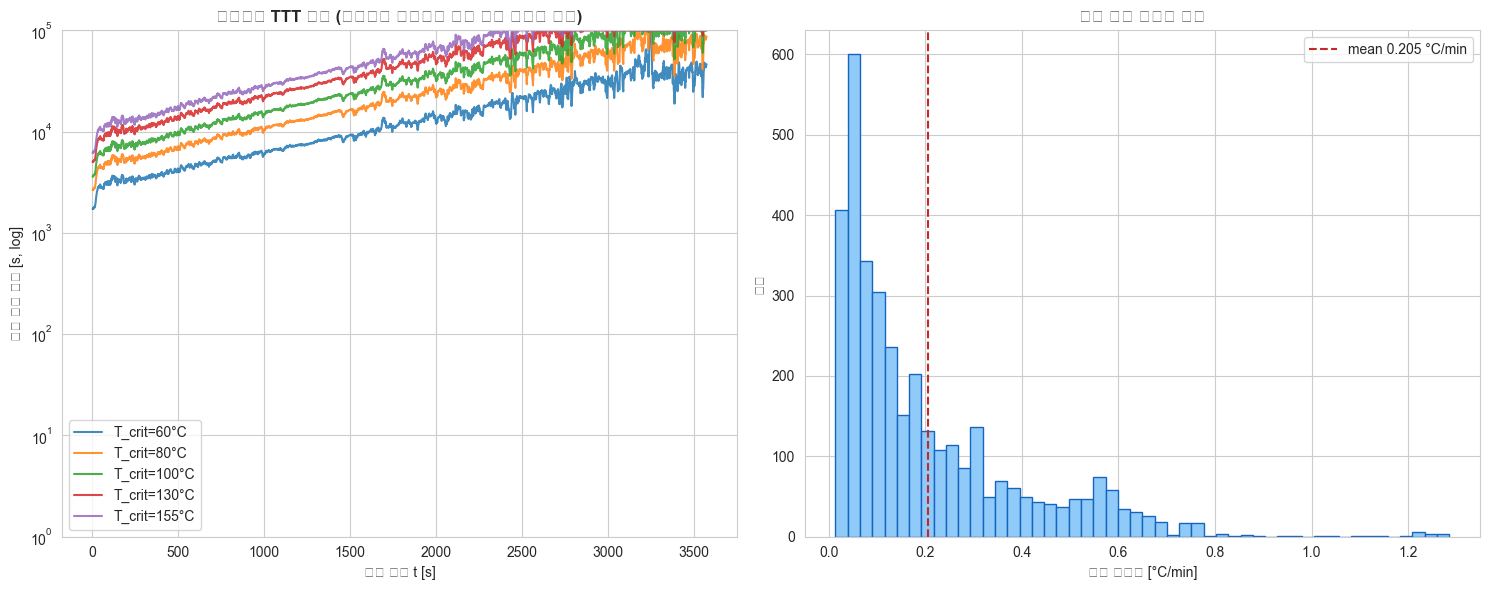

마지막 100s 예측 평균 상승률: +0.036 °C/min
  → 사실상 정상상태. 임계 도달 시나리오는 학습 데이터로 예측 불가 (외삽 불안정).

현재 코어 추정값(H=0 prediction) 마지막 5개:
  t=3568s  →  T_core_pred = 37.17°C
  t=3569s  →  T_core_pred = 37.17°C
  t=3570s  →  T_core_pred = 37.16°C
  t=3571s  →  T_core_pred = 37.16°C
  t=3572s  →  T_core_pred = 37.16°C

💡 임계 도달 데이터 확보 후 → 직접 TTT 회귀 모델로 전환 권장.


In [18]:
# ─── 사용자 파라미터 ─────────────────
T_CRIT_LIST = [60, 80, 100, 130, 155]   # °C — 후보 임계값들 (마진 미정 → 여러 개 표시)
USE_MODEL   = BEST_MODEL_NAME             # Section 7에서 자동 선택
# ─────────────────────────────────────

# 다중 호라이즌 예측을 모두 사용해서 시간축 회귀로 외삽 기울기 산출
# 각 시점 t에서 [pred(t+0), pred(t+30), pred(t+60), pred(t+120)] 4점에 직선 적합 → 기울기
import numpy as np

# 모든 호라이즌에 대해 same model로 학습 후 예측
preds_all = {}
for h in HORIZONS:
    mdl = make_models()[USE_MODEL]
    mdl.fit(scaler.transform(X_all), Y_all[h])
    preds_all[h] = mdl.predict(scaler.transform(X_all))

# 각 행마다 4개 호라이즌 예측 → 최소제곱으로 직선 fit (slope = °C/s)
horizons_arr = np.array(HORIZONS)
preds_matrix = np.column_stack([preds_all[h] for h in HORIZONS])  # (N, len(HORIZONS))

# 직선 y = a + b*t  (b = 상승률)
H = horizons_arr - horizons_arr.mean()
denom = (H * H).sum()
slopes = ((preds_matrix - preds_matrix.mean(axis=1, keepdims=True)) * H).sum(axis=1) / denom
T_core_now_pred = preds_all[0]   # H=0 예측 = 현재 코어 추정값

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 좌: 시간에 따른 외삽 TTT (임계값별)
for T_crit in T_CRIT_LIST:
    ttt = np.where(slopes > 1e-4,
                   (T_crit - T_core_now_pred) / slopes,
                   np.inf)
    ttt = np.where(ttt < 0, np.inf, ttt)  # 이미 임계 넘은 경우 무시
    ttt = np.clip(ttt, 0, 1e5)
    axes[0].plot(df["t_sec"], ttt, label=f"T_crit={T_crit}°C", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_ylim(1, 1e5)
axes[0].set_xlabel("운전 시각 t [s]")
axes[0].set_ylabel("도달 예상 시간 [s, log]")
axes[0].set_title("임계값별 TTT 외삽 (호라이즌 예측들의 직선 회귀 기울기 사용)", fontweight="bold")
axes[0].legend()

# 우: 예측 상승률 분포
axes[1].hist(slopes * 60, bins=50, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(slopes.mean()*60, color=RED, linestyle="--",
                label=f"mean {slopes.mean()*60:.3f} °C/min")
axes[1].set_xlabel("예측 상승률 [°C/min]")
axes[1].set_ylabel("빈도")
axes[1].set_title("모델 예측 상승률 분포", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_ttt_extrapolation.png", dpi=150, bbox_inches="tight")
plt.show()

last_rate = slopes[-100:].mean() * 60
print(f"마지막 100s 예측 평균 상승률: {last_rate:+.3f} °C/min")
if abs(last_rate) < 0.05:
    print("  → 사실상 정상상태. 임계 도달 시나리오는 학습 데이터로 예측 불가 (외삽 불안정).")
print(f"\n현재 코어 추정값(H=0 prediction) 마지막 5개:")
for i in range(-5, 0):
    print(f"  t={df['t_sec'].iloc[i]:.0f}s  →  T_core_pred = {T_core_now_pred[i]:.2f}°C")
print("\n💡 임계 도달 데이터 확보 후 → 직접 TTT 회귀 모델로 전환 권장.")


## Section 10: 모델 가중치 크기 비교 (ESP32 배포 관점)

각 모델을 PRIMARY_H 호라이즌에 대해 학습 → 저장 → **추론에 필요한 파라미터 수**를 추출.
ESP32 플래시/RAM 사용량 추정용 — float32 / int8 양자화 / joblib pickle 3가지 측정.

**비교 기준:**
- `params`: 추론 시 실제로 ESP32 메모리에 올려야 하는 weight 개수
- `float32`: 그대로 C 배열 `float w[]` 로 박았을 때 (= params × 4 B)
- `int8`: 양자화 가정 (= params × 1 B, scale/zero-point 메타 제외 추정)
- `pickle`: joblib 저장 파일 크기 (디스크 — sklearn 메타 포함이라 실제 배포보다 큼)

In [19]:
import joblib

MODELS_DIR = "../output/models"
os.makedirs(MODELS_DIR, exist_ok=True)


def count_inference_params(name, model):
    """ESP32에 올라갈 추론 파라미터 수 + breakdown 문자열."""
    if name == "Linear":
        n = model.coef_.size + 1
        return n, f"coef({model.coef_.size}) + bias(1)"
    if name.startswith("SVD"):
        pca, lr = model.named_steps["pca"], model.named_steps["lr"]
        n = pca.components_.size + pca.mean_.size + lr.coef_.size + 1
        return n, f"pca_comp({pca.components_.size}) + mean({pca.mean_.size}) + lr_coef({lr.coef_.size}) + bias(1)"
    if name.startswith("Poly"):
        poly, lr = model.named_steps["poly"], model.named_steps["lr"]
        return lr.coef_.size + 1, f"poly_coef({lr.coef_.size}) + bias(1)  [expanded {poly.n_output_features_} terms]"
    if name.startswith("DT"):
        n_nodes = model.tree_.node_count
        return n_nodes * 5, f"{n_nodes} nodes × 5 fields"
    if name.startswith("XGB"):
        df_t = model.get_booster().trees_to_dataframe()
        return len(df_t) * 5, f"{len(df_t)} nodes × 5 fields ({df_t['Tree'].nunique()} trees)"
    return 0, "?"


def fmt_bytes(n):
    if n < 1024:    return f"{n:>7d} B"
    if n < 1024**2: return f"{n/1024:>6.2f} KB"
    return f"{n/1024**2:>6.2f} MB"


# 대표 호라이즌(60s)에 대해 5개 모델 재학습 + 저장 + 측정
size_rows = []
print(f"{'='*100}")
print(f"가중치 크기 비교 (PRIMARY_H = {PRIMARY_H}s, 피처 {len(FEATURE_COLS)}개)")
print(f"{'='*100}")
print(f"{'Model':<16} {'MAE':>7} {'R²':>7} {'#params':>10} "
      f"{'float32':>11} {'int8':>10} {'pickle':>11}  breakdown")
print("-" * 100)

for name, model in make_models().items():
    model.fit(X_train_sc, y_train[PRIMARY_H])
    yp = model.predict(X_test_sc)
    mae = mean_absolute_error(y_test[PRIMARY_H], yp)
    r2  = r2_score(y_test[PRIMARY_H], yp)

    n_params, breakdown = count_inference_params(name, model)
    f32_b, i8_b = n_params * 4, n_params * 1

    fname = name.replace("+","_").replace("(","").replace(")","").replace(",","_").replace(" ","")
    pkl = os.path.join(MODELS_DIR, f"{fname}.pkl")
    joblib.dump(model, pkl, compress=3)
    pkl_b = os.path.getsize(pkl)

    print(f"{name:<16} {mae:>7.4f} {r2:>7.4f} {n_params:>10,d} "
          f"{fmt_bytes(f32_b)} {fmt_bytes(i8_b)} {fmt_bytes(pkl_b)}  {breakdown}")
    size_rows.append({"model": name, "MAE": round(mae,4), "R²": round(r2,4),
                      "params": n_params, "float32_B": f32_b, "int8_B": i8_b, "pickle_B": pkl_b})

# Scaler도 같이 배포 필요 (입력 정규화 — 또는 LR 계수에 융합 가능)
sc_path = os.path.join(MODELS_DIR, "scaler.pkl")
joblib.dump(scaler, sc_path, compress=3)
sc_params = scaler.mean_.size + scaler.scale_.size
print("-" * 100)
print(f"{'StandardScaler':<16} {'-':>7} {'-':>7} {sc_params:>10,d} "
      f"{fmt_bytes(sc_params*4)} {fmt_bytes(sc_params*1)} {fmt_bytes(os.path.getsize(sc_path))}  "
      f"mean({scaler.mean_.size}) + scale({scaler.scale_.size})")
print("=" * 100)

# 참고: 1D-CNN 분석값
print("[참고: 같은 작업에 1D-CNN 적용 시 추정값]")
print("  Conv1D(8,k=3) + Dense(16) + Dense(1)  ≈ 200 params  →  float32 800 B / int8 200 B")
print("  실제 .tflite 파일은 헤더/메타 포함 ~3-5 KB")

size_df = pd.DataFrame(size_rows).set_index("model")
size_df


가중치 크기 비교 (PRIMARY_H = 60s, 피처 7개)
Model                MAE      R²    #params     float32       int8      pickle  breakdown
----------------------------------------------------------------------------------------------------
Linear            0.0314  0.9998          8      32 B       8 B     567 B  coef(7) + bias(1)
SVD(3)+LR         0.5780  0.9576         32     128 B      32 B   1.12 KB  pca_comp(21) + mean(7) + lr_coef(3) + bias(1)
Poly(2)+LR        0.0154  1.0000         36     144 B      36 B   1.17 KB  poly_coef(35) + bias(1)  [expanded 35 terms]
DT(d=5)           0.0812  0.9991        315   1.23 KB     315 B   2.45 KB  63 nodes × 5 fields
XGB               0.0110  1.0000     29,700 116.02 KB  29.00 KB  67.67 KB  5940 nodes × 5 fields (200 trees)
----------------------------------------------------------------------------------------------------
StandardScaler         -       -         14      56 B      14 B     603 B  mean(7) + scale(7)
[참고: 같은 작업에 1D-CNN 적용 시 추정값]
  Conv1D(8,k

,MAE,R²,params,float32_B,int8_B,pickle_B
model,,,,,,
Linear,0.0314,0.9998,8,32,8,567
SVD(3)+LR,0.5780,0.9576,32,128,32,1145
Poly(2)+LR,0.0154,1.0000,36,144,36,1202
DT(d=5),0.0812,0.9991,315,1260,315,2505
XGB,0.0110,1.0000,29700,118800,29700,69297


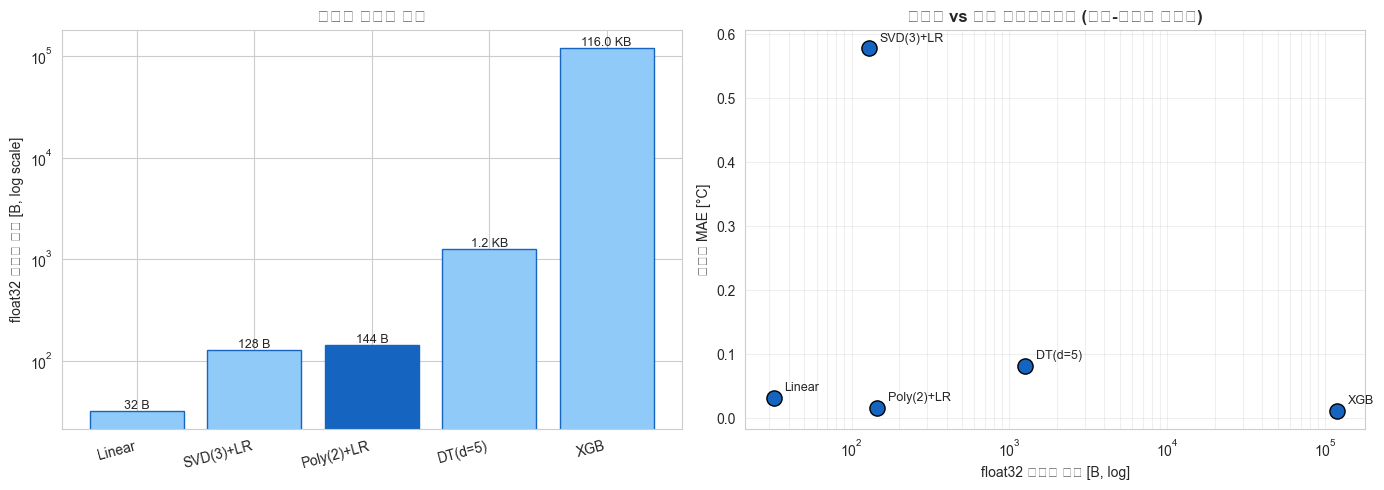

해석: 좌하단(작고 정확)에 가까울수록 ESP32에 적합한 모델.


In [20]:
# 시각화: 정확도(MAE) vs 크기(float32 B) 트레이드오프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: bar — 모델별 float32 가중치 크기 (log scale)
ax = axes[0]
colors = [BLUE_LIGHT if m != "Poly(2)+LR" else BLUE for m in size_df.index]
bars = ax.bar(size_df.index, size_df["float32_B"], color=colors, edgecolor=BLUE)
for b, v in zip(bars, size_df["float32_B"]):
    label = f"{v} B" if v < 1024 else f"{v/1024:.1f} KB"
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.05, label, ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("float32 가중치 크기 [B, log scale]")
ax.set_title("모델별 가중치 크기", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# 우: scatter — MAE vs 크기 (Pareto 시각화)
ax = axes[1]
ax.scatter(size_df["float32_B"], size_df["MAE"], s=120, color=BLUE, edgecolor="black", zorder=3)
for name, row in size_df.iterrows():
    ax.annotate(name, (row["float32_B"], row["MAE"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("float32 가중치 크기 [B, log]")
ax.set_ylabel("테스트 MAE [°C]")
ax.set_title("정확도 vs 크기 트레이드오프 (왼쪽-아래가 베스트)", fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_model_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("해석: 좌하단(작고 정확)에 가까울수록 ESP32에 적합한 모델.")


## Section 11: 가속도 센서 데이터 검증 (진동 → 코어온도 예측 유효성)

**파일:** `Vibration_data_norm_26_05_04_test.csv` (200 Hz, X/Y/Z 3축 + CH4, ~25.7분)

**목적:** 진동 센서가 코어온도 예측에 **추가 정보**를 주는지 검증.

**검증 설계 (공정 비교):**
1. 200Hz 진동 → **1Hz 통계 피처** 다운샘플 (RMS, peak, crest factor, kurtosis per axis)
2. 써미스터 데이터와 시간 동기화 (`T_OFFSET` 파라미터)
3. 진동 커버 구간만 사용해 baseline (써미스터 10개) vs extended (써미스터 10개 + 진동 N개) **동일 데이터셋**에서 학습
4. ΔMAE / ΔR²로 진동 유효성 판정

**시간 정렬 가설:** 진동 CSV의 `t` 컬럼은 "테스트 끝 = 0"이라 음수 (-3690 → -2150). 써미스터 끝점(`t_sec ≈ 3692`)을 기준으로 보면 진동은 써미스터 [2s, 1542s] 구간 커버 (전반부 ~25분만).

In [21]:
from scipy.stats import kurtosis as scipy_kurtosis

VIB_CSV   = "../data/Vibration_data_norm_26_05_04_test.csv"
T_OFFSET  = 0.0            # 진동 t_sec → 써미스터 t_sec 보정값. 동시 시작이면 0.
                            # 정렬 어긋나면 시각화 보고 조정 (예: -2.0)
VIB_FS    = 200             # 200 Hz 가정
WINDOW_S  = 1.0             # 1초 윈도우 (= 200 샘플) 으로 1Hz 피처화

# ── Raw 200Hz 로드 ──
vib_raw = pd.read_csv(VIB_CSV, encoding="cp949", skiprows=3, header=None,
                      usecols=[0, 1, 2, 3, 4, 5],
                      names=["t_abs", "X", "Y", "Z", "CH4", "t_sec_vib"])
vib_raw = vib_raw.dropna(subset=["X", "Y", "Z", "t_sec_vib"]).reset_index(drop=True)

fs_actual = 1.0 / vib_raw["t_sec_vib"].diff().median()
print(f"진동 raw: {len(vib_raw):,}행, fs ≈ {fs_actual:.1f} Hz, "
      f"duration {vib_raw['t_sec_vib'].iloc[-1]:.1f}s")

# 시간 정렬: 진동 → 써미스터 시간축
vib_raw["t_therm"] = vib_raw["t_sec_vib"] + T_OFFSET

# 진동 신호 평균(DC 오프셋) 제거 — 가속도 변동분만 남김
for ax in ["X", "Y", "Z"]:
    vib_raw[f"{ax}_ac"] = vib_raw[ax] - vib_raw[ax].mean()

# ── 1Hz 윈도우별 통계 (정수 t_therm으로 그룹핑) ──
vib_raw["sec_bin"] = vib_raw["t_therm"].astype(int)

def axis_stats(g, ax):
    s = g[f"{ax}_ac"].values
    rms  = np.sqrt(np.mean(s**2)) if len(s) else np.nan
    peak = np.max(np.abs(s))      if len(s) else np.nan
    crest = peak / rms if rms > 1e-9 else np.nan
    kurt  = scipy_kurtosis(s) if len(s) > 3 else np.nan
    return pd.Series({f"{ax}_rms": rms, f"{ax}_peak": peak,
                      f"{ax}_crest": crest, f"{ax}_kurt": kurt})

print("1Hz 다운샘플 + 통계 추출 중...")
vib_1hz = (vib_raw.groupby("sec_bin", group_keys=False)
           .apply(lambda g: pd.concat([axis_stats(g, "X"),
                                       axis_stats(g, "Y"),
                                       axis_stats(g, "Z")]))
           .reset_index().rename(columns={"sec_bin": "t_sec"}))

# 종합 RMS = √(X² + Y² + Z²)
vib_1hz["rms_total"]  = np.sqrt(vib_1hz["X_rms"]**2 + vib_1hz["Y_rms"]**2 + vib_1hz["Z_rms"]**2)
vib_1hz["peak_total"] = vib_1hz[["X_peak", "Y_peak", "Z_peak"]].max(axis=1)

VIB_FEATURES = ["X_rms","Y_rms","Z_rms","rms_total",
                "X_peak","Y_peak","Z_peak","peak_total",
                "X_crest","Y_crest","Z_crest",
                "X_kurt","Y_kurt","Z_kurt"]

print(f"진동 1Hz 행수: {len(vib_1hz)}, 피처: {len(VIB_FEATURES)}")
print(f"진동 t_sec 범위: [{vib_1hz['t_sec'].min()}, {vib_1hz['t_sec'].max()}] "
      f"(써미스터 t_sec 0~{int(df['t_sec'].max())} 중 일부)")
vib_1hz[VIB_FEATURES].describe().round(4)


진동 raw: 308,217행, fs ≈ 200.0 Hz, duration 1541.1s
1Hz 다운샘플 + 통계 추출 중...
진동 1Hz 행수: 1542, 피처: 14
진동 t_sec 범위: [0, 1541] (써미스터 t_sec 0~3571 중 일부)


,X_rms,Y_rms,Z_rms,rms_total,X_peak,Y_peak,Z_peak,peak_total,X_crest,Y_crest,Z_crest,X_kurt,Y_kurt,Z_kurt
count,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000,1542.0000
mean,0.0297,0.0660,0.0156,0.0742,0.0773,0.1222,0.0422,0.1225,2.6127,1.8480,2.7062,-0.0349,-1.3595,-0.1225
std,0.0040,0.0042,0.0014,0.0051,0.0141,0.0091,0.0074,0.0111,0.3693,0.0805,0.4357,2.2395,0.0735,0.8466
min,0.0059,0.0168,0.0125,0.0223,0.0294,0.0200,0.0259,0.0294,2.0468,1.1513,1.4666,-1.1712,-2.0000,-1.8502
25%,0.0285,0.0656,0.0149,0.0736,0.0730,0.1224,0.0424,0.1224,2.3813,1.8259,2.5991,-0.3931,-1.3873,-0.7335
50%,0.0297,0.0664,0.0155,0.0744,0.0730,0.1224,0.0424,0.1224,2.4980,1.8447,2.7408,-0.2166,-1.3578,-0.2104
75%,0.0309,0.0671,0.0162,0.0751,0.0730,0.1224,0.0424,0.1224,2.6518,1.8671,2.8763,0.0005,-1.3273,0.4360
max,0.1327,0.0949,0.0386,0.1598,0.4049,0.1848,0.1106,0.4049,5.0471,2.3972,4.1020,61.6819,-0.2214,2.6654


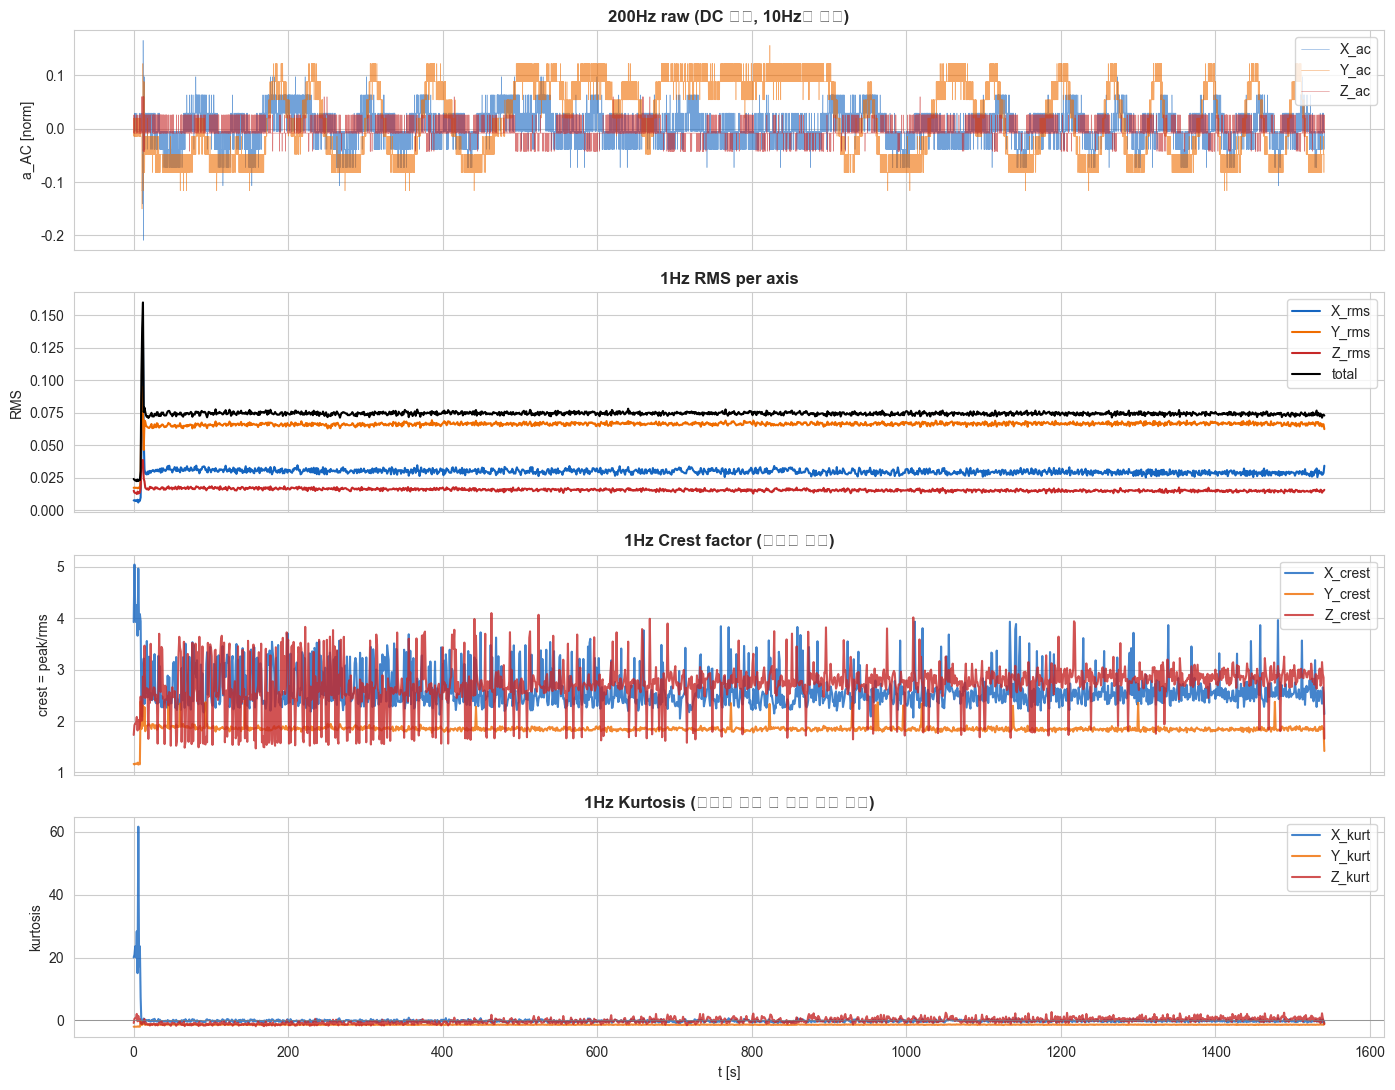

In [22]:
# 진동 피처 시계열 시각화
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

# (1) raw 200Hz 신호 (다운샘플해서 표시 — 너무 빽빽함)
sub = vib_raw.iloc[::20]   # 10Hz 정도로 표시
axes[0].plot(sub["t_therm"], sub["X_ac"], color=BLUE,   label="X_ac", alpha=0.6, linewidth=0.4)
axes[0].plot(sub["t_therm"], sub["Y_ac"], color=ORANGE, label="Y_ac", alpha=0.6, linewidth=0.4)
axes[0].plot(sub["t_therm"], sub["Z_ac"], color=RED,    label="Z_ac", alpha=0.6, linewidth=0.4)
axes[0].set_ylabel("a_AC [norm]"); axes[0].legend(loc="upper right")
axes[0].set_title("200Hz raw (DC 제거, 10Hz로 표시)", fontweight="bold")

# (2) RMS per axis + total
axes[1].plot(vib_1hz["t_sec"], vib_1hz["X_rms"], color=BLUE,   label="X_rms")
axes[1].plot(vib_1hz["t_sec"], vib_1hz["Y_rms"], color=ORANGE, label="Y_rms")
axes[1].plot(vib_1hz["t_sec"], vib_1hz["Z_rms"], color=RED,    label="Z_rms")
axes[1].plot(vib_1hz["t_sec"], vib_1hz["rms_total"], color="black", label="total", linewidth=1.5)
axes[1].set_ylabel("RMS"); axes[1].legend(loc="upper right")
axes[1].set_title("1Hz RMS per axis", fontweight="bold")

# (3) Crest factor
for ax_name, c in zip(["X","Y","Z"], [BLUE, ORANGE, RED]):
    axes[2].plot(vib_1hz["t_sec"], vib_1hz[f"{ax_name}_crest"], color=c, label=f"{ax_name}_crest", alpha=0.8)
axes[2].set_ylabel("crest = peak/rms"); axes[2].legend(loc="upper right")
axes[2].set_title("1Hz Crest factor (충격성 지표)", fontweight="bold")

# (4) Kurtosis
for ax_name, c in zip(["X","Y","Z"], [BLUE, ORANGE, RED]):
    axes[3].plot(vib_1hz["t_sec"], vib_1hz[f"{ax_name}_kurt"], color=c, label=f"{ax_name}_kurt", alpha=0.8)
axes[3].axhline(0, color="gray", linewidth=0.5)
axes[3].set_xlabel("t [s]"); axes[3].set_ylabel("kurtosis")
axes[3].legend(loc="upper right")
axes[3].set_title("1Hz Kurtosis (베어링 결함 등 충격 신호 검출)", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/12_vibration_features.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# ── 써미스터 + 진동 통합 ──
# df는 이미 core_t60 등 절대 코어 타깃 포함. t_sec 키로 inner-join.
df_with_t = df.copy()
df_with_t["t_sec"] = df_with_t["t_sec"].astype(int)
vib_1hz["t_sec"]   = vib_1hz["t_sec"].astype(int)

merged = df_with_t.merge(vib_1hz[["t_sec"] + VIB_FEATURES], on="t_sec", how="inner").dropna()
print(f"통합 데이터셋: {len(merged)}행 (써미스터 {len(df)}행 ∩ 진동 커버 구간)")
print(f"시간 범위: {merged['t_sec'].min()}~{merged['t_sec'].max()}s")

# ── 동일 데이터로 baseline (ambient+room만) vs extended (+진동) ──
THERM_FEATURES = FEATURE_COLS                              # 7개 (Section 1 정의 — ambient+room+t)
EXT_FEATURES   = THERM_FEATURES + VIB_FEATURES             # 7 + 14 = 21개

X_therm = merged[THERM_FEATURES].values
X_ext   = merged[EXT_FEATURES].values
y_h     = merged[PRIMARY_TARGET].values

idx_tr, idx_te = train_test_split(np.arange(len(merged)), test_size=0.2, random_state=42)

def fit_eval(X, name):
    Xtr, Xte = X[idx_tr], X[idx_te]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    out = []
    candidates = {
        "Linear":     LinearRegression(),
        "Poly(2)+LR": Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                ("lr",   LinearRegression())]),
        "XGB":        XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                   random_state=42, verbosity=0),
    }
    for mname, m in candidates.items():
        m.fit(Xtr_s, y_h[idx_tr])
        yp = m.predict(Xte_s)
        out.append({"set": name, "model": mname,
                    "n_features": X.shape[1],
                    "MAE": mean_absolute_error(y_h[idx_te], yp),
                    "R²":  r2_score(y_h[idx_te], yp)})
    return out

print("\n학습 중...")
rows = fit_eval(X_therm, "baseline (ambient+room만)") + fit_eval(X_ext, "extended (+진동)")
comp_df = pd.DataFrame(rows)
print("\n=== Baseline vs Extended (진동 커버 구간 동일 샘플) ===")
print(comp_df.to_string(index=False))

# ΔMAE / ΔR²
print("\n=== 진동 추가 효과 (Δ = extended − baseline) ===")
for mname in ["Linear", "Poly(2)+LR", "XGB"]:
    base = comp_df[(comp_df["set"].str.contains("baseline")) & (comp_df["model"]==mname)].iloc[0]
    ext  = comp_df[(comp_df["set"].str.contains("extended")) & (comp_df["model"]==mname)].iloc[0]
    dmae = ext["MAE"] - base["MAE"]
    dr2  = ext["R²"]  - base["R²"]
    verdict = "✓ 개선" if (dmae < -0.0005 or dr2 > 0.001) else "≈ 차이 미미" if abs(dmae) < 0.001 else "✗ 악화"
    print(f"  [{mname:11s}] ΔMAE={dmae:+.4f}  ΔR²={dr2:+.4f}  → {verdict}")


통합 데이터셋: 1540행 (써미스터 3570행 ∩ 진동 커버 구간)
시간 범위: 2~1541s

학습 중...

=== Baseline vs Extended (진동 커버 구간 동일 샘플) ===
                     set      model  n_features      MAE       R²
baseline (ambient+room만)     Linear           7 0.020261 0.999913
baseline (ambient+room만) Poly(2)+LR           7 0.006716 0.999990
baseline (ambient+room만)        XGB           7 0.011007 0.999971
          extended (+진동)     Linear          21 0.018607 0.999923
          extended (+진동) Poly(2)+LR          21 0.007161 0.999986
          extended (+진동)        XGB          21 0.011252 0.999969

=== 진동 추가 효과 (Δ = extended − baseline) ===
  [Linear     ] ΔMAE=-0.0017  ΔR²=+0.0000  → ✓ 개선
  [Poly(2)+LR ] ΔMAE=+0.0004  ΔR²=-0.0000  → ≈ 차이 미미
  [XGB        ] ΔMAE=+0.0002  ΔR²=-0.0000  → ≈ 차이 미미


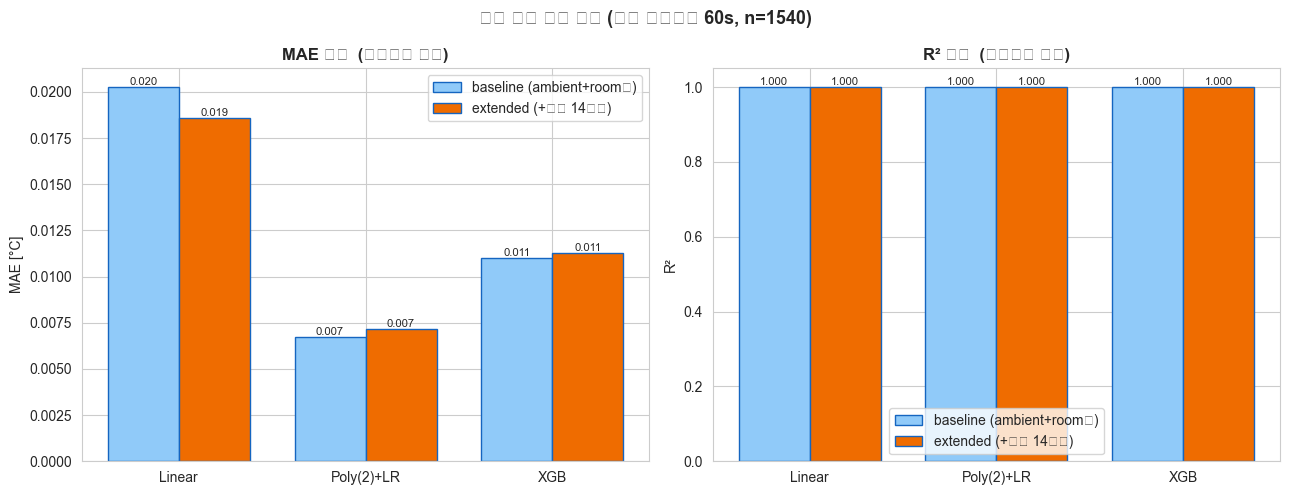

In [24]:
# 시각화: baseline vs extended R²/MAE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_x = ["Linear", "Poly(2)+LR", "XGB"]
x = np.arange(len(models_x))
w = 0.38

for ax, metric, ylabel, lower_better in [
    (axes[0], "MAE", "MAE [°C]", True),
    (axes[1], "R²",  "R²",       False),
]:
    base_vals = [comp_df[(comp_df["set"].str.contains("baseline")) & (comp_df["model"]==m)][metric].values[0] for m in models_x]
    ext_vals  = [comp_df[(comp_df["set"].str.contains("extended")) & (comp_df["model"]==m)][metric].values[0] for m in models_x]
    ax.bar(x - w/2, base_vals, width=w, color=BLUE_LIGHT, edgecolor=BLUE, label="baseline (ambient+room만)")
    ax.bar(x + w/2, ext_vals,  width=w, color=ORANGE,     edgecolor=BLUE, label="extended (+진동 14피처)")
    for i, (b, e) in enumerate(zip(base_vals, ext_vals)):
        ax.text(i - w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, e, f"{e:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(models_x)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric} 비교  ({'낮을수록 좋음' if lower_better else '높을수록 좋음'})", fontweight="bold")
    ax.legend()

plt.suptitle(f"진동 피처 추가 효과 (대표 호라이즌 {PRIMARY_H}s, n={len(merged)})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_vibration_validation.png", dpi=150, bbox_inches="tight")
plt.show()


### Section 11 해석 가이드

**ΔMAE/ΔR² 부호로 판정:**
- **ΔMAE 음수 + ΔR² 양수** → 진동이 코어온도 예측에 **유효한 추가 정보** 제공. ESP32에 가속도 센서 포함 가치 있음.
- **둘 다 미미** (±0.001 이내) → 정상 운전 영역에서는 진동이 **온도와 거의 독립적**이거나 시계열 일부만 보고 있어 학습 어려움.
- **악화** (오버피팅) → 피처 수 대비 데이터 부족 (1500행에 24피처) — 진동 피처 일부만 골라서 재시도 권장 (예: rms_total + kurtosis만).

**현재 데이터 한계 — 결과 해석 시 주의:**
- 정상 스테디스테이트라 진동 자체가 거의 변화 없음 (RMS 일정) → 학습 신호 약함
- **이상 시나리오 (베어링 마모, locked rotor, unbalance)** 데이터가 들어와야 진동의 진짜 가치 (kurtosis, crest factor 급증) 확인 가능
- 이 검증은 "**파이프라인이 정상 통합되는지**" + "**정상 운전에서 진동이 추가 신호 주는지**" 두 가지만 답함

**T_OFFSET 조정:** 만약 ΔMAE이 양수(악화)면 시간 정렬이 틀렸을 가능성. Section 11.1 코드 셀의 `T_OFFSET` 값을 ±10s 정도 바꿔보면서 시각화에서 RMS 변화가 코어온도 변화와 동기화되는지 확인.